Name:Wafa Karim Khan

Msc(Data science & Big Data Analytics)

College: B.K Birla College of Arts, Science and Commerce kalyan.

Task6:Handwritten Digit Recognition with Neural Networks

**Import necessary libraries**

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt


**Load and preprocess the MNIST dataset**

In [2]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape the input data and scale pixel values to the range [0, 1]
X_train = X_train.reshape(-1, 28 * 28) / 255.0
X_test = X_test.reshape(-1, 28 * 28) / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


**Build the neural network architecture**

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),  
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

#This code defines a sequential model with two hidden layers (128 and 64 neurons respectively) and 
#an output layer with 10 neurons (since there are 10 classes).

**Compile the model**

In [5]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', #measures the difference between predicted values and actual labels.
              metrics=['accuracy'])

#I am using the Adam optimizer and sparse categorical cross-entropy loss function for multi-class classification.
#included accuracy as a metric to monitor during training.

**Train the model**

In [6]:
#training the model for 10 epochs with a batch size of 32.
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8739 - loss: 0.4317 - val_accuracy: 0.9571 - val_loss: 0.1361
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9686 - loss: 0.1062 - val_accuracy: 0.9653 - val_loss: 0.1127
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 994us/step - accuracy: 0.9778 - loss: 0.0702 - val_accuracy: 0.9733 - val_loss: 0.0859
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 995us/step - accuracy: 0.9840 - loss: 0.0505 - val_accuracy: 0.9732 - val_loss: 0.0913
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9875 - loss: 0.0379 - val_accuracy: 0.9723 - val_loss: 0.0965
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.9908 - loss: 0.0302 - val_accuracy: 0.9771 - val_loss: 0.0821
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9908 - loss: 0.0262 - val_accuracy: 0.9732 - val_loss: 0.0960
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9926 - loss: 0.0

**Evaluate the model**

In [13]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step
Accuracy: 0.9764
Precision: 0.9765810939252222
Recall: 0.9764
F1 Score: 0.9764085037086842


In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[ 962    1    3    0    1    1    5    2    4    1]
 [   0 1122    3    2    0    0    2    2    4    0]
 [   0    3 1009    5    1    0    0    9    5    0]
 [   0    0    3  996    0    2    0    2    4    3]
 [   1    0    4    0  967    0    1    2    0    7]
 [   2    0    0   27    2  850    2    1    7    1]
 [   2    3    0    2    6    7  938    0    0    0]
 [   1    1    6    2    0    0    0 1012    2    4]
 [   0    0    6   12    2    5    0    6  939    4]
 [   3    2    2    6   13    1    1    7    5  969]]


Observations:
The model seems to be performing well on classifying data points.For example, there are 1122 instances where the actual class was 2 and the model also predicted 2.

**Visualize performance metrics**

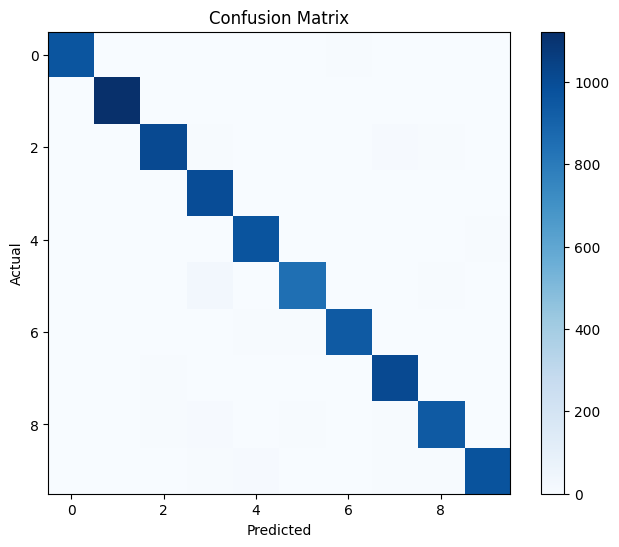

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Darker colors represent a higher number of correctly classified data points. As the color gets lighter, it indicates a decreasing number of correct classifications. Strengths: Categories where the model excels (dark diagonal cells). Weaknesses: Categories where the model struggles (lighter off-diagonal cells). 